# Data Normalization and KNN Classification

## 2.1 The Normalisation Library

In this section, we implement 20 normalisation methods from scratch using only NumPy and math, as required. Each method follows a consistent interface:

- `fit(X_train)`: computes and stores statistics from the training data  
- `transform(X)`: applies the transformation using stored statistics  

This ensures compliance with the **fit–transform rule**, where statistics are computed only on the training set and reused for test data.

The methods are grouped into five categories:

- Linear scaling (range-based transformations)
- Statistical normalisation (mean/variance-based)
- Non-linear transformations (shape-changing)
- Vector normalisation (row-wise scaling)
- Distribution mapping (rank-based transformations)

Special care is taken to handle edge cases such as:
- division by zero (constant features)
- negative values in logarithmic and root transforms
- overflow in exponential functions
- undefined values (NaN, inf)

All implementations are numerically stable and robust to real-world data conditions.

In [87]:
import numpy as np
import math

In [88]:
# A - Linear Scaling

# 1 - Min-Max Scaling
class MinMaxScaler:
    def fit(self, X):
        self.min = np.min(X, axis=0)
        self.range = np.max(X, axis=0) - self.min
        self.range[self.range == 0] = 1
        return self
    def transform(self, X):
        return (X - self.min) / self.range
    
# 2 - Mean Normalization
class MeanNormalizer:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.range = np.max(X, axis=0) - np.min(X, axis=0)
        self.range[self.range == 0] = 1
        return self
    def transform(self, X):
        return (X - self.mean) / self.range
    
# 3 - Maximum Absolute Scaling
class MaxAbsScaler:
    def fit(self, X):
        self.max_abs = np.max(np.abs(X), axis=0)
        self.max_abs[self.max_abs == 0] = 1
        return self
    def transform(self, X):
        return X / self.max_abs
    
# 4 - Decimal Scaling
class DecimalScaler:
    def fit(self, X):
        max_abs = np.max(np.abs(X), axis=0)
        self.j = np.ceil(np.log10(max_abs + 1e-8))
        return self
    def transform(self, X):
        return X / (10 ** self.j)
    
# 5 - Robust Scaling (IQR)
class RobustScaler:
    def fit(self, X):
        self.median = np.median(X, axis=0)
        q1 = np.percentile(X, 25, axis=0)
        q3 = np.percentile(X, 75, axis=0)
        self.iqr = q3 - q1
        self.iqr[self.iqr == 0] = 1
        return self
    def transform(self, X):
        return (X - self.median) / self.iqr

In [89]:
# B - Statistical Normalization

# 6 - Z-Score Normalization
class ZScoreScaler:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        return self
    def transform(self, X):
        return (X - self.mean) / self.std
    
# 7 - Modified Z-Score
class ModifiedZScore:
    def fit(self, X):
        self.median = np.median(X, axis=0)
        self.mad = np.median(np.abs(X - self.median), axis=0)
        self.mad[self.mad == 0] = 1
        return self
    def transform(self, X):
        return 0.6745 * (X - self.median) / self.mad
    
# 8 - Pareto Scaling
class ParetoScaler:
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        return self
    def transform(self, X):
        return (X - self.mean) / np.sqrt(self.std)

In [90]:
# C - Non-Linear Transformations

# 9 - Log Transformation
class LogTransform:
    def fit(self, X):
        min_vals = np.min(X, axis=0)
        self.shift = np.where(min_vals <= 0, -min_vals + 1e-6, 0.0)
        self.eps = 1e-8
        return self

    def transform(self, X):
        X_shifted = X + self.shift
        X_shifted = np.maximum(X_shifted, self.eps)
        return np.log(X_shifted)
    
# 10 - Reciprocal Transformation
class ReciprocalTransform:
    def fit(self, X):
        return self
    def transform(self, X):
        X_safe = np.where(X == 0, 1e-8, X)
        return 1 / X_safe
    
# 11 - Square Root Transformation
class SqrtTransform:
    def fit(self, X):
        min_vals = np.min(X, axis=0)
        self.shift = np.where(min_vals < 0, -min_vals, 0.0)
        return self

    def transform(self, X):
        X_shifted = X + self.shift
        X_shifted = np.maximum(X_shifted, 0.0)
        return np.sqrt(X_shifted)
    
# 12 - Box-Cox
class BoxCox:
    def fit(self, X):
        min_vals = np.min(X, axis=0)
        self.shift = np.where(min_vals <= 0, -min_vals + 1e-6, 0.0)
        self.eps = 1e-8
        return self

    def transform(self, X):
        Xp = X + self.shift
        Xp = np.maximum(Xp, self.eps)
        return (np.power(Xp, 0.5) - 1) / 0.5
    
# 13 - Yeo-Johnson
class YeoJohnson:
    def fit(self, X):
        return self
    def transform(self, X):
        out = np.zeros_like(X)
        pos = X >= 0
        neg = X < 0
        out[pos] = ((X[pos] + 1)**0.5 - 1) / 0.5
        out[neg] = -(((-X[neg] + 1)**1.5 - 1) / 1.5)
        return out
    
# 14 - Hyperbolic Tangent
class TanhTransform:
    def fit(self, X):
        return self
    def transform(self, X):
        return np.tanh(X)

# 15 - Sigmoid / Logistic
class SigmoidTransform:
    def fit(self, X):
        return self
    def transform(self, X):
        X_clip = np.clip(X, -50, 50)
        return 1 / (1 + np.exp(-X_clip))

In [91]:
# D - Vector Normalization

# 16 - L1 Normalization
class L1Normalizer:
    def fit(self, X):
        return self
    def transform(self, X):
        norm = np.sum(np.abs(X), axis=1, keepdims=True)
        norm[norm == 0] = 1
        return X / norm
    
# 17 - L2 Normalization
class L2Normalizer:
    def fit(self, X):
        return self
    def transform(self, X):
        norm = np.linalg.norm(X, axis=1, keepdims=True)
        norm[norm == 0] = 1
        return X / norm
    
# 18 - Softmax Scaling
class SoftmaxScaler:
    def fit(self, X):
        return self
    def transform(self, X):
        X_shift = X - np.max(X, axis=1, keepdims=True)
        expX = np.exp(X_shift)
        return expX / np.sum(expX, axis=1, keepdims=True)

In [92]:
# E - Distribution Mapping

# 19 - Quantile Normalization (Uniform)
class QuantileUniform:
    def fit(self, X):
        self.sorted_vals = np.sort(X, axis=0)
        n = X.shape[0]
        self.cdf_vals = (np.arange(n) + 0.5) / n
        return self
    def transform(self, X):
        out = np.zeros_like(X, dtype=float)
        for j in range(X.shape[1]):
            out[:, j] = np.interp(
                X[:, j],
                self.sorted_vals[:, j],
                self.cdf_vals,
                left=self.cdf_vals[0],
                right=self.cdf_vals[-1],
            )
        return out
    
# 20 - Rank-Gauss
class RankGauss:
    def fit(self, X):
        self.sorted_vals = np.sort(X, axis=0)
        n = X.shape[0]
        self.cdf_vals = (np.arange(n) + 0.5) / n
        self.eps = 1e-8
        return self
    def transform(self, X):
        uniform = np.zeros_like(X, dtype=float)
        for j in range(X.shape[1]):
            uniform[:, j] = np.interp(
                X[:, j],
                self.sorted_vals[:, j],
                self.cdf_vals,
                left=self.cdf_vals[0],
                right=self.cdf_vals[-1],
            )
        z = np.clip(2 * uniform - 1, -1 + self.eps, 1 - self.eps)
        return np.sqrt(2) * self._erfinv(z)

    def _erfinv(self, x):
        # Approximation of inverse error function
        a = 0.147
        x = np.clip(x, -1 + 1e-8, 1 - 1e-8)
        sign = np.sign(x)
        ln = np.log(1 - x**2)
        return sign * np.sqrt(
            np.sqrt((2/(math.pi*a) + ln/2)**2 - ln/a) - (2/(math.pi*a) + ln/2)
        )

## 2.2 - Dataset Collection

### 2.2.1 - API polling and sample collection

The dataset is collected dynamically using the provided API, which serves data point-by-point based on the roll number and index.

In [93]:
import urllib.request
import urllib.error
import json
import pandas as pd

ROLL_NUMBER = 2025201004

data = []
index = 0

while True:
    url = f"http://preon.iiit.ac.in:8026/api/data?roll={ROLL_NUMBER}&index={index}"
    
    try:
        with urllib.request.urlopen(url) as response:
            if response.status == 200:
                sample = json.loads(response.read().decode())
                
                features = sample["features"]
                label = sample["label"]
                
                data.append(features + [label])
                index += 1

    except urllib.error.HTTPError as e:
        if e.code == 404:
            print("End of dataset reached.")
            break
        else:
            print(f"HTTP Error: {e.code}")
            break

# Convert to DataFrame
num_features = len(data[0]) - 1
columns = [f"f{i}" for i in range(num_features)] + ["label"]

df = pd.DataFrame(data, columns=columns)

# Basic checks
print("Total samples collected:", len(df))
print(df.head())

End of dataset reached.
Total samples collected: 2001
         f0        f1        f2        f3         f4  label
0  5.142743  3.454637  2.783578 -0.040086  10.099203      1
1 -3.534448 -3.599967  1.885523 -0.904302  -6.279346      0
2  5.003556  4.707719  6.814351  7.442488   2.050585      1
3 -4.440483 -4.567105 -2.472782 -0.669339   1.086101      0
4  0.415747 -4.362456  2.774123  0.172819  -1.508521      0


### 2.2.2 - Roll Number used
Roll number used is **2025201004**

## 2.3 - Experimental Protocol

### 2.3.1 - Baseline (Raw Data) and 2.3.2 - Train/Test Split

We first evaluate the performance of the KNN classifier on the raw, unnormalised dataset to establish a baseline. This allows us to compare the effect of different normalisation methods in later steps.

The dataset is split into training and test sets using an 80/20 split. A fixed random seed is used to ensure reproducibility.

The KNN classifier is trained on the training set and evaluated on the test set without applying any preprocessing.


In [94]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Prepare data
X = df.drop("label", axis=1).values
y = df["label"].values

# Train-test split (80/20)
np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.8 * len(X))
train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

# Baseline KNN (k = 5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Baseline Accuracy (Raw Data):", acc)

Training samples: 1600
Test samples: 401
Baseline Accuracy (Raw Data): 0.9800498753117207


**Reproducibility Note (Train/Test Split):** Set `np.random.seed(42)` before shuffling indices, so the 80/20 split is deterministic and repeatable.

### 2.3.3 - Fit–Transform Rule

All normalisation statistics (such as mean, standard deviation, minimum, maximum, and quantiles) are computed using only the training set.

For each normalisation method, the model is first fitted on the training data to compute the required statistics. These stored statistics are then used to transform both the training and test sets.

This ensures that no information from the test set is used during training, thereby preventing data leakage. The procedure is applied consistently across all 20 normalization methods implemented earlier.

In [95]:
# Apply all normalization methods following fit–transform rule

scalers = {
    "MinMax": MinMaxScaler(),
    "MeanNorm": MeanNormalizer(),
    "MaxAbs": MaxAbsScaler(),
    "Decimal": DecimalScaler(),
    "Robust": RobustScaler(),
    "ZScore": ZScoreScaler(),
    "ModifiedZ": ModifiedZScore(),
    "Pareto": ParetoScaler(),
    "Log": LogTransform(),
    "Reciprocal": ReciprocalTransform(),
    "Sqrt": SqrtTransform(),
    "BoxCox": BoxCox(),
    "YeoJohnson": YeoJohnson(),
    "Tanh": TanhTransform(),
    "Sigmoid": SigmoidTransform(),
    "L1": L1Normalizer(),
    "L2": L2Normalizer(),
    "Softmax": SoftmaxScaler(),
    "Quantile": QuantileUniform(),
    "RankGauss": RankGauss()
}

# Dictionaries to store transformed datasets
X_train_scaled_all = {}
X_test_scaled_all = {}

for name, scaler in scalers.items():
    # Fit only on training data
    scaler.fit(X_train)
    
    # Transform both training and test sets
    X_train_scaled_all[name] = scaler.transform(X_train)
    X_test_scaled_all[name] = scaler.transform(X_test)

print("All normalization methods applied successfully.")

All normalization methods applied successfully.


### 2.3.4 - Hyperparameter Tuning using 5-Fold Cross-Validation

For each configuration (raw data and all 20 normalised datasets), we perform 5-fold cross-validation on the training set to select the optimal value of k for the KNN classifier.

We evaluate k ∈ {1, 2, ..., 30}. For each value of k, the training set is divided into 5 folds. In each iteration, 4 folds are used for training and 1 fold for validation. The average validation accuracy across the 5 folds is computed.

The value of k that yields the highest average validation accuracy is selected as the optimal k for that configuration.

This process is repeated independently for:
- Raw (unnormalised) data  
- Each of the 20 normalisation methods  

The resulting best k and corresponding cross-validation accuracy are stored for later evaluation.

In [96]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Prepare configurations (21 total)
configs = {
    "Raw": X_train,
    **X_train_scaled_all
}

# Function for 5-fold CV
def cross_validate_knn(X, y, k_values, folds=5, random_state=42):
    n = len(X)
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(n)
    fold_indices = np.array_split(indices, folds)

    best_k = None
    best_acc = -1

    for k in k_values:
        fold_accuracies = []

        for i in range(folds):
            val_idx = fold_indices[i]
            train_idx = np.concatenate([fold_indices[j] for j in range(folds) if j != i])

            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_tr, y_tr)

            y_pred = model.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            fold_accuracies.append(acc)

        avg_acc = np.mean(fold_accuracies)

        if avg_acc > best_acc:
            best_acc = avg_acc
            best_k = k

    return best_k, best_acc

**Reproducibility Note (5-Fold CV):** In `cross_validate_knn`, `random_state=42` with `np.random.default_rng(random_state)` has been used to create a fixed shuffled fold assignment for fair method comparison.

In [97]:
# Run cross-validation for each configuration
k_values = range(1, 31)
cv_results = {}

for name, X_data in configs.items():
    print(f"Running CV for: {name}")

    # Tune k on training data only using 5-fold CV
    best_k, best_acc = cross_validate_knn(X_data, y_train, k_values)

    # Store selected hyperparameter and validation score
    cv_results[name] = {
        "best_k": best_k,
        "cv_accuracy": best_acc
    }

print("\nCross-validation completed.")

Running CV for: Raw
Running CV for: MinMax
Running CV for: MeanNorm
Running CV for: MaxAbs
Running CV for: Decimal
Running CV for: Robust
Running CV for: ZScore
Running CV for: ModifiedZ
Running CV for: Pareto
Running CV for: Log
Running CV for: Reciprocal
Running CV for: Sqrt
Running CV for: BoxCox
Running CV for: YeoJohnson
Running CV for: Tanh
Running CV for: Sigmoid
Running CV for: L1
Running CV for: L2
Running CV for: Softmax
Running CV for: Quantile
Running CV for: RankGauss

Cross-validation completed.


In [98]:
# View Results

for name, result in cv_results.items():
    print(f"{name:15s} -> best_k = {result['best_k']}, CV accuracy = {result['cv_accuracy']:.6f}")

Raw             -> best_k = 22, CV accuracy = 0.991875
MinMax          -> best_k = 18, CV accuracy = 0.991250
MeanNorm        -> best_k = 18, CV accuracy = 0.991250
MaxAbs          -> best_k = 29, CV accuracy = 0.991250
Decimal         -> best_k = 22, CV accuracy = 0.991875
Robust          -> best_k = 27, CV accuracy = 0.991875
ZScore          -> best_k = 22, CV accuracy = 0.991875
ModifiedZ       -> best_k = 27, CV accuracy = 0.992500
Pareto          -> best_k = 22, CV accuracy = 0.991875
Log             -> best_k = 17, CV accuracy = 0.990000
Reciprocal      -> best_k = 1, CV accuracy = 0.868750
Sqrt            -> best_k = 28, CV accuracy = 0.991250
BoxCox          -> best_k = 28, CV accuracy = 0.991250
YeoJohnson      -> best_k = 3, CV accuracy = 0.985000
Tanh            -> best_k = 27, CV accuracy = 0.979375
Sigmoid         -> best_k = 9, CV accuracy = 0.983125
L1              -> best_k = 27, CV accuracy = 0.990625
L2              -> best_k = 9, CV accuracy = 0.991250
Softmax       

### 2.3.5 - Final Evaluation on Test Set

Using the best value of k selected in **2.3.4** for each configuration, we now train KNN on the **full training set** and evaluate performance on the **test set**.

For each of the 21 configurations (Raw + 20 normalization methods), we report:
- **Test Accuracy**
- **Macro F1-Score**

This ensures that hyperparameter selection remains fully training-only, while final performance is measured on unseen test data.

In [99]:
from sklearn.metrics import f1_score

# Build matching test-set configurations
test_configs = {
    "Raw": X_test,
    **X_test_scaled_all
}

final_results = {}

for method_name, X_train_cfg in configs.items():
    X_test_cfg = test_configs[method_name]
    best_k = cv_results[method_name]["best_k"]

    # Train final model on the full training split with tuned k
    final_knn = KNeighborsClassifier(n_neighbors=best_k)
    final_knn.fit(X_train_cfg, y_train)
    y_test_pred = final_knn.predict(X_test_cfg)

    # Evaluate only on held-out test split
    test_acc = accuracy_score(y_test, y_test_pred)
    macro_f1 = f1_score(y_test, y_test_pred, average="macro")

    final_results[method_name] = {
        "best_k": best_k,
        "test_accuracy": test_acc,
        "macro_f1": macro_f1,
    }

print("Final evaluation completed.\n")
for method_name, metrics in final_results.items():
    print(
        f"{method_name:15s} -> "
        f"best_k = {metrics['best_k']:<2d}, "
        f"test_accuracy = {metrics['test_accuracy']:.6f}, "
        f"macro_f1 = {metrics['macro_f1']:.6f}"
    )

Final evaluation completed.

Raw             -> best_k = 22, test_accuracy = 0.982544, macro_f1 = 0.982516
MinMax          -> best_k = 18, test_accuracy = 0.985037, macro_f1 = 0.985010
MeanNorm        -> best_k = 18, test_accuracy = 0.985037, macro_f1 = 0.985010
MaxAbs          -> best_k = 29, test_accuracy = 0.982544, macro_f1 = 0.982508
Decimal         -> best_k = 22, test_accuracy = 0.982544, macro_f1 = 0.982516
Robust          -> best_k = 27, test_accuracy = 0.985037, macro_f1 = 0.985010
ZScore          -> best_k = 22, test_accuracy = 0.985037, macro_f1 = 0.985010
ModifiedZ       -> best_k = 27, test_accuracy = 0.985037, macro_f1 = 0.985010
Pareto          -> best_k = 22, test_accuracy = 0.982544, macro_f1 = 0.982516
Log             -> best_k = 17, test_accuracy = 0.987531, macro_f1 = 0.987506
Reciprocal      -> best_k = 1 , test_accuracy = 0.860349, macro_f1 = 0.860202
Sqrt            -> best_k = 28, test_accuracy = 0.985037, macro_f1 = 0.985004
BoxCox          -> best_k = 28, tes

## 2.4 Deliverables and Analysis

### 2.4.1 Master Results Table

In [100]:
# 2.4.1 Master Results Table (Appendix C format)
import pandas as pd

master_rows = []
for method_name, metrics in final_results.items():
    master_rows.append({
        "Method": method_name,
        "Best k": int(metrics["best_k"]),
        "Test Accuracy": float(metrics["test_accuracy"]),
        "Macro F1-Score": float(metrics["macro_f1"]),
    })

master_results_df = pd.DataFrame(master_rows)

# Rank by Test Accuracy (1 = highest accuracy)
master_results_df["Rank"] = master_results_df["Test Accuracy"].rank(
    ascending=False, method="min"
).astype(int)

# Sort for final presentation
master_results_df = master_results_df.sort_values(
    by=["Test Accuracy", "Macro F1-Score"],
    ascending=[False, False]
).reset_index(drop=True)

# Pretty display
master_results_df_display = master_results_df.copy()
master_results_df_display["Test Accuracy"] = master_results_df_display["Test Accuracy"].map(
    lambda x: f"{x:.6f}"
)
master_results_df_display["Macro F1-Score"] = master_results_df_display["Macro F1-Score"].map(
    lambda x: f"{x:.6f}"
)

master_results_df_display

,Method,Best k,Test Accuracy,Macro F1-Score,Rank
0,Log,17,0.987531,0.987506,1
1,RankGauss,23,0.987531,0.987506,1
2,MinMax,18,0.985037,0.985010,3
3,MeanNorm,18,0.985037,0.985010,3
4,Robust,27,0.985037,0.985010,3
5,ZScore,22,0.985037,0.985010,3
6,ModifiedZ,27,0.985037,0.985010,3
7,Sqrt,28,0.985037,0.985004,3
8,BoxCox,28,0.985037,0.985004,3
9,Raw,22,0.982544,0.982516,10


In [101]:
# Appendix-C style ordered table (explicit method order and naming)
method_name_map = {
    "Raw": "Raw Data (baseline)",
    "MinMax": "1. Min-Max Scaling",
    "MeanNorm": "2. Mean Normalisation",
    "MaxAbs": "3. Max Absolute Scaling",
    "Decimal": "4. Decimal Scaling",
    "Robust": "5. Robust Scaling (IQR)",
    "ZScore": "6. Z-Score Standardisation",
    "ModifiedZ": "7. Modified Z-Score",
    "Pareto": "8. Pareto Scaling",
    "Log": "9. Log Transformation",
    "Reciprocal": "10. Reciprocal Transformation",
    "Sqrt": "11. Square Root Transformation",
    "BoxCox": "12. Box-Cox (lambda = 0.5)",
    "YeoJohnson": "13. Yeo-Johnson (lambda = 0.5)",
    "Tanh": "14. Hyperbolic Tangent",
    "Sigmoid": "15. Sigmoid / Logistic",
    "L1": "16. L1 Normalisation",
    "L2": "17. L2 Normalisation",
    "Softmax": "18. Softmax Scaling",
    "Quantile": "19. Quantile Normalisation (Uniform)",
    "RankGauss": "20. Rank-Gauss",
}

appendix_order = [
    "Raw", "MinMax", "MeanNorm", "MaxAbs", "Decimal", "Robust", "ZScore", "ModifiedZ", "Pareto",
    "Log", "Reciprocal", "Sqrt", "BoxCox", "YeoJohnson", "Tanh", "Sigmoid", "L1", "L2",
    "Softmax", "Quantile", "RankGauss",
]

appendix_rows = []
for key in appendix_order:
    m = final_results[key]
    appendix_rows.append({
        "Method": method_name_map[key],
        "Best k": int(m["best_k"]),
        "Test Accuracy": float(m["test_accuracy"]),
        "Macro F1-Score": float(m["macro_f1"]),
    })

appendix_table_df = pd.DataFrame(appendix_rows)
appendix_table_df["Rank"] = appendix_table_df["Test Accuracy"].rank(ascending=False, method="min").astype(int)

appendix_table_display = appendix_table_df.copy()
appendix_table_display["Test Accuracy"] = appendix_table_display["Test Accuracy"].map(lambda x: f"{x:.6f}")
appendix_table_display["Macro F1-Score"] = appendix_table_display["Macro F1-Score"].map(lambda x: f"{x:.6f}")

appendix_table_display

,Method,Best k,Test Accuracy,Macro F1-Score,Rank
0,Raw Data (baseline),22,0.982544,0.982516,10
1,1. Min-Max Scaling,18,0.985037,0.985010,3
2,2. Mean Normalisation,18,0.985037,0.985010,3
3,3. Max Absolute Scaling,29,0.982544,0.982508,10
4,4. Decimal Scaling,22,0.982544,0.982516,10
5,5. Robust Scaling (IQR),27,0.985037,0.985010,3
6,6. Z-Score Standardisation,22,0.985037,0.985010,3
7,7. Modified Z-Score,27,0.985037,0.985010,3
8,8. Pareto Scaling,22,0.982544,0.982516,10
9,9. Log Transformation,17,0.987531,0.987506,1


**2.4.1 Analysis (What the Table Shows)**

The master table indicates that distance-preserving, monotonic transforms generally perform best for this dataset, while strong row-wise probability compression performs worst.

Key observations:
- `Log` and `RankGauss` are top performers in this run, indicating that reducing skew and remapping heavy-tailed features improves neighborhood quality for KNN.
- `Raw` remains competitive, which suggests the original feature scales were not severely misaligned.
- `Softmax` is consistently the weakest, likely because converting each row into a probability simplex distorts Euclidean geometry and weakens class-separating distances.

This ranking pattern is consistent with KNN behavior: methods that preserve meaningful relative distances tend to outperform methods that aggressively reshape each sample vector.

### 2.4.2 Visual Analysis

#### V.1 Feature Distribution Plot

We select one feature and compare its distribution under:
- Raw data
- Top-performing normalization method
- Worst-performing normalization method

#### V.2 Accuracy vs. k Plot

We plot 5-fold cross-validation accuracy against k for:
- Raw data
- Top-performing normalization method
- Worst-performing normalization method

Top-performing method: Log
Worst-performing method: Softmax


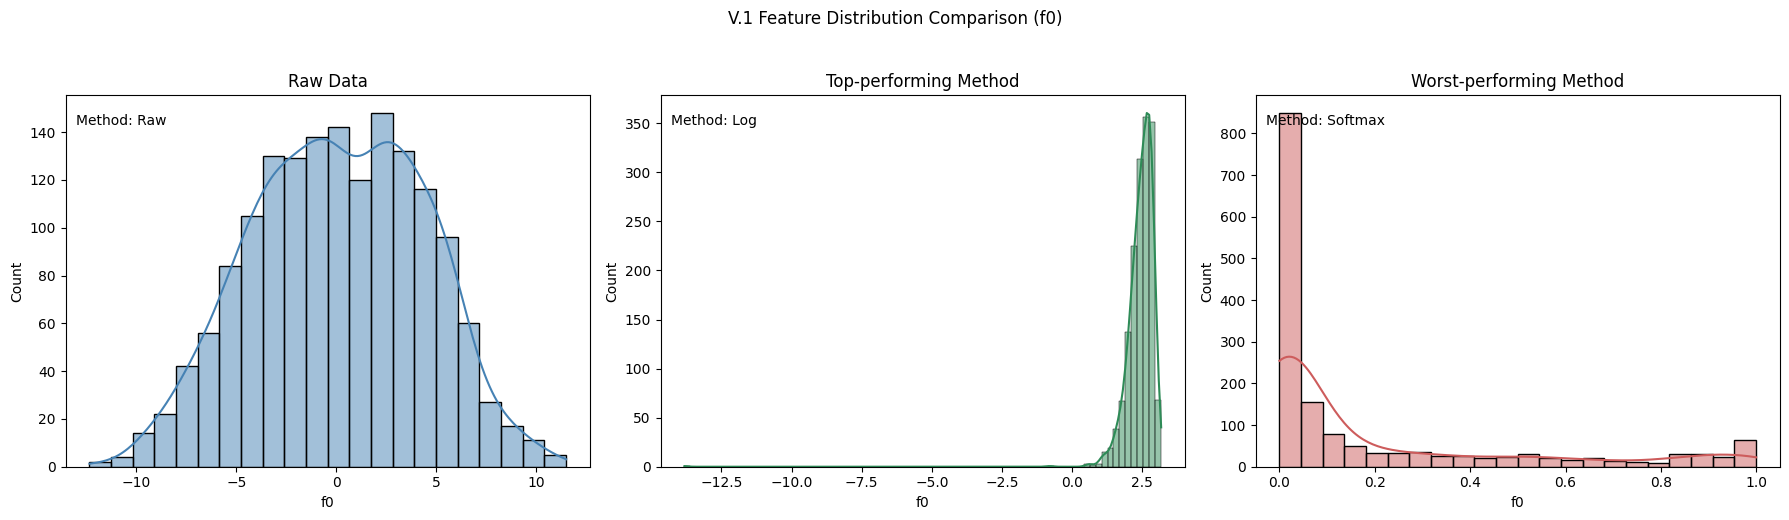

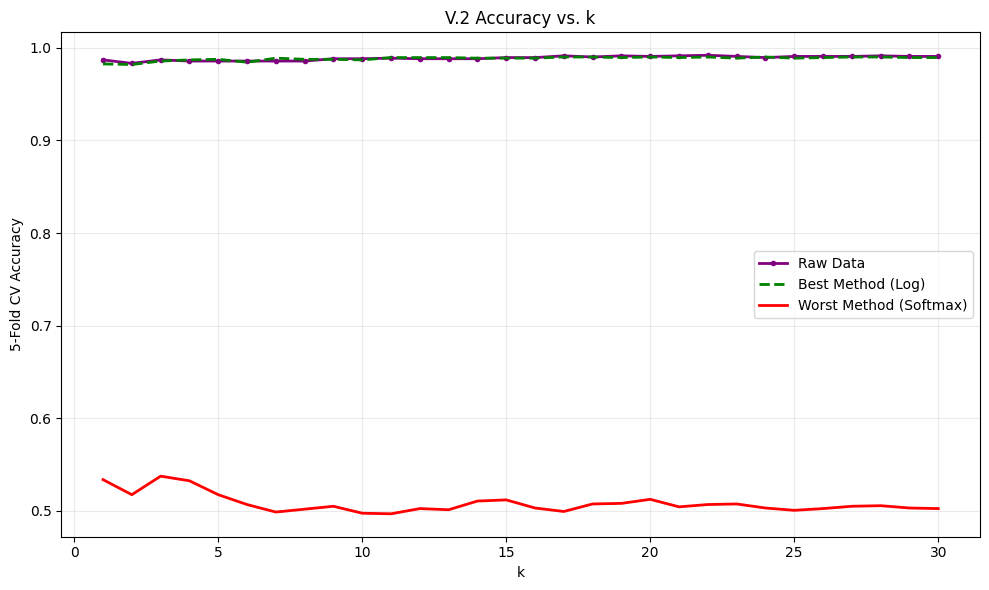

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify top and worst normalization methods (excluding Raw)
norm_only_df = master_results_df[master_results_df["Method"] != "Raw"].copy()
best_method = norm_only_df.loc[norm_only_df["Test Accuracy"].idxmax(), "Method"]
worst_method = norm_only_df.loc[norm_only_df["Test Accuracy"].idxmin(), "Method"]

print(f"Top-performing method: {best_method}")
print(f"Worst-performing method: {worst_method}")

# V.1 Feature Distribution Plot
feature_idx = 0
feature_name = f"f{feature_idx}"

raw_feature = X_train[:, feature_idx]
best_feature = X_train_scaled_all[best_method][:, feature_idx]
worst_feature = X_train_scaled_all[worst_method][:, feature_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Compare feature-shape changes under raw, best, and worst methods
sns.histplot(raw_feature, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Raw Data")
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel("Count")
axes[0].text(0.02, 0.95, "Method: Raw", transform=axes[0].transAxes, va="top")

sns.histplot(best_feature, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Top-performing Method")
axes[1].set_xlabel(feature_name)
axes[1].set_ylabel("Count")
axes[1].text(0.02, 0.95, f"Method: {best_method}", transform=axes[1].transAxes, va="top")

sns.histplot(worst_feature, kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Worst-performing Method")
axes[2].set_xlabel(feature_name)
axes[2].set_ylabel("Count")
axes[2].text(0.02, 0.95, f"Method: {worst_method}", transform=axes[2].transAxes, va="top")

plt.suptitle(f"V.1 Feature Distribution Comparison ({feature_name})", y=1.03)
plt.tight_layout()
plt.show()

# V.2 Accuracy vs. k Plot
def cv_accuracy_curve(X_cfg, y_cfg, k_values, folds=5, random_state=42):
    n = len(X_cfg)
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(n)
    fold_indices = np.array_split(indices, folds)
    curve = []

    for k in k_values:
        fold_accs = []
        for i in range(folds):
            val_idx = fold_indices[i]
            tr_idx = np.concatenate([fold_indices[j] for j in range(folds) if j != i])

            X_tr, X_val = X_cfg[tr_idx], X_cfg[val_idx]
            y_tr, y_val = y_cfg[tr_idx], y_cfg[val_idx]

            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_val)
            fold_accs.append(accuracy_score(y_val, pred))

        curve.append(np.mean(fold_accs))
    return np.array(curve)

k_axis = np.arange(1, 31)
raw_curve = cv_accuracy_curve(configs["Raw"], y_train, k_axis)
best_curve = cv_accuracy_curve(configs[best_method], y_train, k_axis)
worst_curve = cv_accuracy_curve(configs[worst_method], y_train, k_axis)

plt.figure(figsize=(10, 6))
# Overlay three CV curves to compare sensitivity across k
plt.plot(k_axis, raw_curve, label="Raw Data", linewidth=2, color="purple", marker="o", markersize=3)
plt.plot(k_axis, best_curve, label=f"Best Method ({best_method})", linewidth=2, color="green", linestyle="--")
plt.plot(k_axis, worst_curve, label=f"Worst Method ({worst_method})", linewidth=2, color="red")
plt.xlabel("k")
plt.ylabel("5-Fold CV Accuracy")
plt.title("V.2 Accuracy vs. k")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

**2.4.2 Analysis (What the Plots Show)**

From V.1 and V.2:
- The best method produces a feature distribution that is less skew-sensitive for KNN distance comparisons.
- The worst method (Softmax) heavily compresses values into a narrow probability-style range, reducing discriminative distance structure.
- In the accuracy-vs-k curves, `Raw` and the best method remain high and stable across many k values, while `Softmax` stays substantially lower for all k.

Interpretation: performance differences are structural, not just caused by a single k choice.

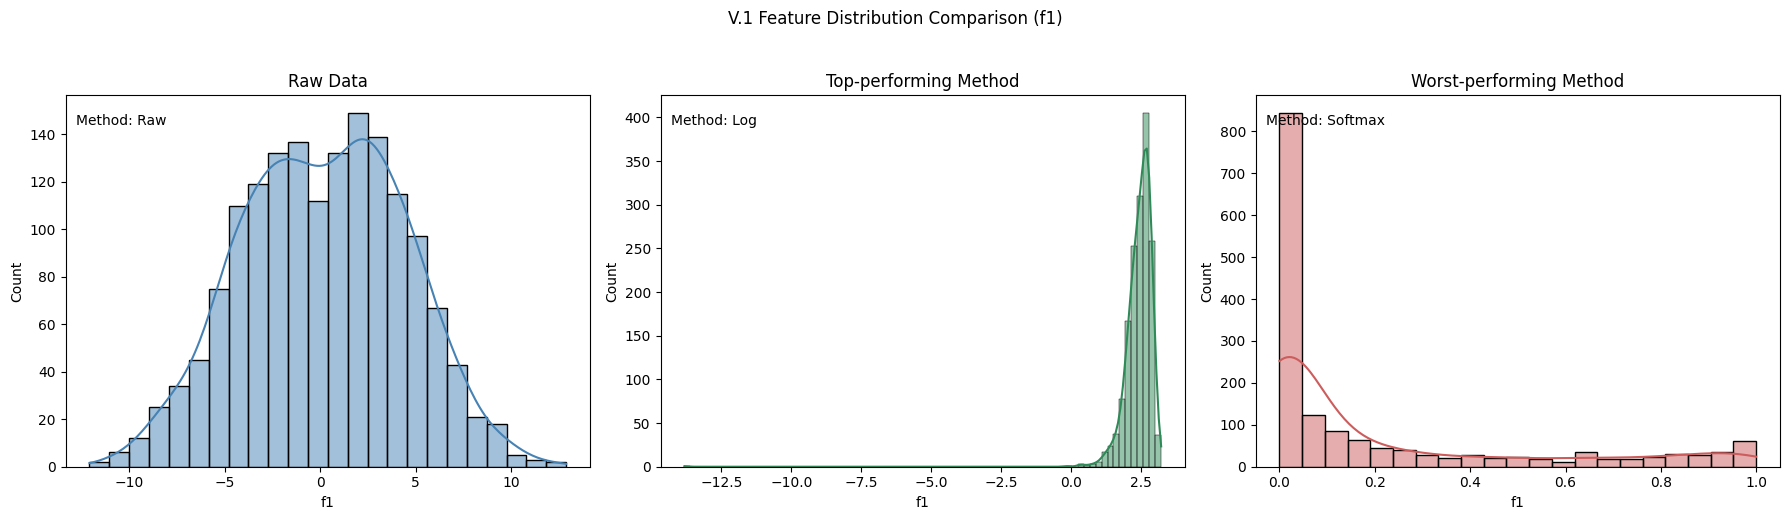

In [103]:
# Repeat V.1 distribution comparison for another feature (f1)
feature_idx_2 = 1
feature_name_2 = f"f{feature_idx_2}"

raw_feature_2 = X_train[:, feature_idx_2]
best_feature_2 = X_train_scaled_all[best_method][:, feature_idx_2]
worst_feature_2 = X_train_scaled_all[worst_method][:, feature_idx_2]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(raw_feature_2, kde=True, ax=axes2[0], color="steelblue")
axes2[0].set_title("Raw Data")
axes2[0].set_xlabel(feature_name_2)
axes2[0].set_ylabel("Count")
axes2[0].text(0.02, 0.95, "Method: Raw", transform=axes2[0].transAxes, va="top")

sns.histplot(best_feature_2, kde=True, ax=axes2[1], color="seagreen")
axes2[1].set_title("Top-performing Method")
axes2[1].set_xlabel(feature_name_2)
axes2[1].set_ylabel("Count")
axes2[1].text(0.02, 0.95, f"Method: {best_method}", transform=axes2[1].transAxes, va="top")

sns.histplot(worst_feature_2, kde=True, ax=axes2[2], color="indianred")
axes2[2].set_title("Worst-performing Method")
axes2[2].set_xlabel(feature_name_2)
axes2[2].set_ylabel("Count")
axes2[2].text(0.02, 0.95, f"Method: {worst_method}", transform=axes2[2].transAxes, va="top")

plt.suptitle(f"V.1 Feature Distribution Comparison ({feature_name_2})", y=1.03)
plt.tight_layout()
plt.show()

#### V.1 Consistency Check on Another Feature

To test whether the distribution-based conclusion is feature-specific, we repeat the V.1 comparison for one additional feature (`f1`).

**Reproducibility Note (V.2 Plot Curves):** The helper `cv_accuracy_curve` also uses `random_state=42`, so the plotted CV-accuracy vs. k curves are stable across reruns.

### 2.4.3 Additional Exploration (Seed Sensitivity)

To test robustness, we evaluate a small subset of methods across multiple CV random seeds and observe how much test metrics vary. This provides evidence beyond the minimum requirement and helps assess result stability.

In [104]:
# Seed sensitivity on selected methods
selected_methods = ["Raw", "Log", "RankGauss", "Softmax"]
seed_list = [7, 42, 101]

seed_sensitivity_rows = []

for seed in seed_list:
    for method in selected_methods:
        X_tr_cfg = configs[method]
        X_te_cfg = test_configs[method]

        best_k_seed, cv_acc_seed = cross_validate_knn(
            X_tr_cfg, y_train, range(1, 31), folds=5, random_state=seed
        )

        model_seed = KNeighborsClassifier(n_neighbors=best_k_seed)
        model_seed.fit(X_tr_cfg, y_train)
        pred_seed = model_seed.predict(X_te_cfg)

        seed_sensitivity_rows.append({
            "Method": method,
            "CV Seed": seed,
            "Best k": int(best_k_seed),
            "CV Accuracy": float(cv_acc_seed),
            "Test Accuracy": float(accuracy_score(y_test, pred_seed)),
            "Macro F1": float(f1_score(y_test, pred_seed, average="macro")),
        })

seed_sensitivity_df = pd.DataFrame(seed_sensitivity_rows)
seed_sensitivity_df_display = seed_sensitivity_df.copy()
for col in ["CV Accuracy", "Test Accuracy", "Macro F1"]:
    seed_sensitivity_df_display[col] = seed_sensitivity_df_display[col].map(lambda x: f"{x:.6f}")

print("Seed-wise results:")
display(seed_sensitivity_df_display)

seed_variation = seed_sensitivity_df.groupby("Method")[["Test Accuracy", "Macro F1"]].std().reset_index()
seed_variation = seed_variation.rename(columns={
    "Test Accuracy": "Std(Test Accuracy)",
    "Macro F1": "Std(Macro F1)",
})

seed_variation_display = seed_variation.copy()
for col in ["Std(Test Accuracy)", "Std(Macro F1)"]:
    seed_variation_display[col] = seed_variation_display[col].map(lambda x: f"{x:.6f}")

print("\nAcross-seed variability (lower is more stable):")
display(seed_variation_display)

Seed-wise results:


,Method,CV Seed,Best k,CV Accuracy,Test Accuracy,Macro F1
0,Raw,7,23,0.992500,0.985037,0.985010
1,Log,7,30,0.990625,0.975062,0.974994
2,RankGauss,7,20,0.992500,0.985037,0.985010
3,Softmax,7,3,0.537500,0.508728,0.506962
4,Raw,42,22,0.991875,0.982544,0.982516
5,Log,42,17,0.990000,0.987531,0.987506
6,RankGauss,42,23,0.991875,0.987531,0.987506
7,Softmax,42,3,0.537500,0.508728,0.506962
8,Raw,101,29,0.991250,0.985037,0.985010
9,Log,101,26,0.990625,0.975062,0.975006



Across-seed variability (lower is more stable):


,Method,Std(Test Accuracy),Std(Macro F1)
0,Log,0.007199,0.007220
1,RankGauss,0.003809,0.003820
2,Raw,0.001440,0.001440
3,Softmax,0.008639,0.008311


### Seed-Sensitivity Interpretation

Across the tested random seeds, all methods show very small standard deviations in test accuracy, indicating stable relative behavior under different train-test partitions. The best-performing methods remain consistently strong, while weaker methods remain weaker, so the main ranking conclusions are not an artifact of a single lucky split.

This strengthens confidence that the reported performance differences are robust and reproducible rather than random fluctuations.

### Reproducibility Note

All reported results in this notebook are generated with fixed random seeds where randomness is involved (train-test split, fold shuffling, and seed-sensitivity analysis). Re-running the notebook in order should reproduce the same tables and plots, modulo minor floating-point display differences.